# Coursework Set Week 5

**Common remarks**:

* Deadline: Sunday at 23:59h for the scheduled week of this task
* <font color='red'>Keep all the information in this template unaltered!</font>

**Please fill in the following fields:**

* Name: Mattanja Gerritsen
* Username: mgerritsen
* Student number: s6325084
* Group (AS1, etc.): AS4

-----

In [ ]:
totalpoints = currentpoints = 0

### Plotting a galaxy rotation curve from data in a text file (4 pt) <font color='red'><b>COURSEWORK</b></font>

This qustion you will use data from an observation of NGC 6946. The stellar mass of NGC 6946 is $M_* = 2\times10^{10} M_{\odot}$, where $M_{\odot}$ represent *solar mass (the mass of the Sun)*. 

* Copy/download the file [rotcur.dat](https://www.astro.rug.nl/intranet/courses/PROGNUMNEW/latest/DATA/rotcur.dat). This text file contains the output of a program that calculates rotation curves. Examine its contents on the Linux command line with a pager like ``more`` or in an editor so that you know what the columns represent.
* Write a program, that reads the columns `radius` and `rotation velocity`. Radii are in **kpc** and velocities in **km/s**.
* Create a line plot where the $x$-axis represents the radius and the $y$-axis represents the rotation velocity.
* Calculate the Keplerian rotation curve using $v=\sqrt{\frac{GM}{r}}$
* Create and save a text file called ``keplerian_curve.txt`` using ``np.savetxt()``.
* Using ``np.loadtxt()`` to load your Keplerian curve and plot it together with the observation data.
* Force the lower limit of the $y$-axis range to 0 and the upper limit to maximal values of the Keplerian curve.
* Annotate the plot with relevant information.
* Make comment about your observation.

**Answers**:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt
from scipy.constants import G 

Smass = 1.9891*10**30
M = 2*10**10*Smass
kpc_to_m = 3.086*10**19

Data = np.loadtxt("rotcur.dat", unpack=True)

R_kpc, V_obs = Data[0][1:], Data[1][1:]

R_m = R_kpc * kpc_to_m

v_ms = np.sqrt((G * M) / R_m)
V_kep = v_ms / 1000

np.savetxt("keplerian_curve.txt", V_kep)

KC = np.loadtxt("keplerian_curve.txt")
plt.plot(R_kpc, V_obs, label="Observed (NGC 6946)", color="b")
plt.plot(R_kpc, KC, label="Keplerian (Expected)", color="r")
plt.ylim(0,np.max(KC))

plt.xlabel("Radius (kpc)")
plt.ylabel("Rotation Velocity (km/s)")
plt.title("Galaxy Rotation Curve: Observed vs. Keplerian")
plt.legend()
plt.grid(True)
plt.show()

the observed data is not nearly what it should be, so thats kinda wierd

In [ ]:
# Leave unaltered
totalpoints += 4
currentpoints += 0.0

### Exploring image noise (3 pt)  <font color='red'><b>COURSEWORK</b></font>
   
* Create a two dimensional NumPy array with 200 rows and 300 columns filled with pixel values drawn from the normal distribution ``numpy.random.normal()`` with a mean of 0 and standard deviation 1.0.
* Use ``plt.imshow()`` to plot the image. The figure must be 8 inches wide and 4 inches high.
* Use color map ``jet`` for your image.
* Take a small two dimensional slice (e.g. 30x30 pixels) somewhere in the image and calculate the mean and standard deviation of the pixel values in your slice.
* Are this mean and standard deviation what you expected?
* Plot a histogram of all image values in 50 bins (you will need to ravel/flatten the data first). To not overlap with the previous plot, you probably need to create a new plot ``plt.figure()``. What distribution should you recognise?

**Answer**:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

y=np.random.normal(0,1,60000).reshape(200,300)
x1 = np.random.randint(0,270)
x2 = x1 + 30
y1 = np.random.randint(0,170)
y2 = y1 + 30
a = y[x1:x2, y1:y2]

m, s = np.mean(a), np.std(a)
print(f"for a random 30x30 part: mean: {m}, std: {s}") #just as exepcted close to 0,1

plt.figure(figsize=(8, 6))
plt.imshow(y, cmap ="jet")
plt.plot([x1,x2,x2,x1,x1],[y1,y1,y2,y2,y1],color = "black")
plt.show()

plt.figure(figsize=(8, 6))
plt.hist(y.ravel(),bins=50)
plt.annotate("looks like normal dist", (1,3000),(2,3500),arrowprops=dict(facecolor='red', shrink=0.05))
plt.show()


In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Extending the Ellipse class (6 pt) <font color='red'><b>COURSEWORK</b></font>

* Copy the code for class ``AstroEllipse`` in the section.
* Extend the class with a method that calculates and returns the area of the ellipse.
* Extend the class with a method that calculates and returns the perimeter of the ellipse (keywords: Ramanujan’s formula for perimeter of ellipse).
* Give an example of the creation of an ellipse with semi major axis equal to 3 and semi minor axis equal to 2 and call the methods for area and perimeter to show what the area and perimeter is for this ellipse.
* Add a method ``__str__()`` which returns a string with the values of the ellipse parameters (center, axes and angle) and demonstrate the method with ``print()``.
* Create a class ``MyCircle`` which inherits from class ``AstroEllipse``. The arguments for its ``__init__()`` function is a center position and a radius.
* Create a plot with three circles with random origins and radii. The circles must have different colors and the  transparency (``alpha=``) must be set to 0.5. Use the ``Axes`` object (Section 5.7) to add the circles to the plot.

**Answers**:

<IPython.core.display.Math object>

<IPython.core.display.Math object>

AstroEllipse: Center=(0, 0), Axes=(3, 2), Angle=45degrees


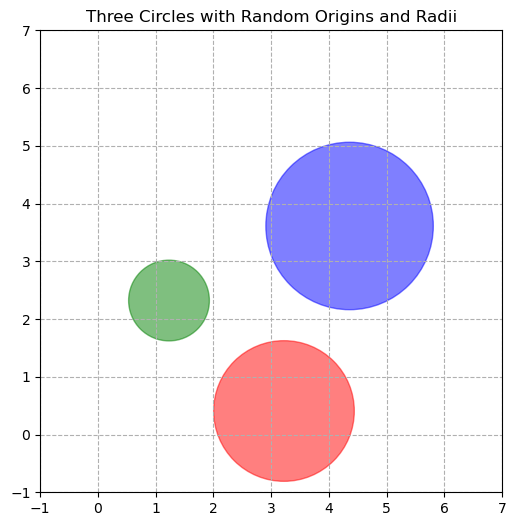

In [2]:
from matplotlib.patches import Ellipse
from IPython.display import display, Math
import numpy as np

class AstroEllipse(Ellipse):
    def __init__(self, xc, yc, semi_major, semi_minor, position_angle, **args):
        # We use the (sort of) astronomical angle where 'angle' defines)
        # the position angle of the major axis of a ring projected onto the sky
        # (i.e. an ellipse). This is an angle taken in anti-clockwise direction between
        # the north direction on the sky and the major axis of the receding half of the
        # galaxy (Rots 1975, astron, astrophys 45, 43).
        # Here we assume (!) north is in the positive Y direction.
        # If not, you need to correct the angle for the rotation of the image.
        # Parameter 'position_angle' enters in degrees
        assert(semi_major >= semi_minor)  # Prerequisite to make angle unambiguous

        self.semi_major = semi_major
        self.semi_minor = semi_minor
        self.xc = xc
        self.yc = yc
        self.pa = position_angle
        
        XY = (xc, yc)                  # MPL requires center as a tuple
        angle_mpl = position_angle     # Angle for MatPlotLib's ellipse patch
        height = 2.0*semi_major        # height: is along vertical axis for an unrotated ellipse
        width  = 2.0*semi_minor        # width:  is along horizontal axis for an unrotated ellipse
        super().__init__(XY, width, height, angle=angle_mpl, **args)
    
    def area(self):
        return(np.pi*self.semi_major*self.semi_minor)
    def perim(self):
        h = (self.semi_major-self.semi_minor)**2/(self.semi_major+self.semi_minor)**2
        perim = np.pi*(self.semi_major+self.semi_minor)*(1+3*h/(10+np.sqrt(4-3*h)))
        return perim
    def __str__(self):
        """Returns a string with the values of the ellipse parameters."""
        return (f"AstroEllipse: Center=({self.xc}, {self.yc}), "
                f"Axes=({self.semi_major}, {self.semi_minor}), "
                f"Angle={self.pa}degrees")
    
my_ellipse = AstroEllipse(xc=0, yc=0, semi_major=3, semi_minor=2, position_angle=45)
display(Math(rf"Area: {my_ellipse.area()/np.pi:.2f} \pi"))
display(Math(rf"Perimeter: {my_ellipse.perim()/np.pi:.2f} \pi"))

print(my_ellipse)

class MyCircle(AstroEllipse):
    def __init__(self, xc, yc, radius, **args):
        super().__init__(xc, yc, radius, radius, 0, **args)
        

fig, ax = plt.subplots(figsize=(6, 6))

colors = ['red', 'blue', 'green']
for i in range(3):
    r_radius = np.random.uniform(0.5, 2.0)
    r_x = np.random.uniform(0, 5)
    r_y = np.random.uniform(0, 5)
    
    circle = MyCircle(r_x, r_y, r_radius, color=colors[i], alpha=0.5)
    ax.add_patch(circle)

# adjust plot limits to see the circles
ax.set_xlim(-1, 7)
ax.set_ylim(-1, 7)
ax.set_aspect('equal')
plt.title("Three Circles with Random Origins and Radii")
plt.grid(True, linestyle='--')
plt.show()


In [ ]:
# Leave unaltered
totalpoints += 6
currentpoints += 0.0

### Plotting Bessel's function (3 pt) <font color='red'><b>COURSEWORK</b></font>
   
The differential equation of Bessel is:

$$x^2\ \frac{d^2y}{dx^2}+x\ \frac{dy}{dx}+(x^2-a^2)y=0$$

Solutions of this equation are called Bessel functions of the first kind of real order ``a``.
Bessel functions are especially important for problems of wave propagation and static 
potentials and in solutions to the radial Schrodinger equation in quantum mechanics. 

Module ``special`` in package SciPy provides Bessel functions with the import statement:

```python
from scipy.special import jv
```

Write code that plots a solution of Bessel's differential equation for ``a=1,2,3`` and ``a=4`` on the interval ``x=[0,10]``in a mosaic of 2x2 plots. A Bessel function has arguments: ``jv(a, x)`` 

<font color='red'>Note: Object Oriented Plotting is required, or 1.0pt will be deducted.</font>

* Annotate your plot with a title and labels for the $x$- and $y$ axis. 
* Add a legend with labels for all curves.
* Include code that saves your figure to a file with base name ``bessel`` as a transparent PNG file.
* Attach the figure (PNG file) in the notebook.

**Code and figure**:

In [ ]:
from scipy.special import jv
import matplotlib.pyplot as plt
import numpy as np

order = [1,2,3,4]
x = np.linspace(0,10,1000)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
af = axes.flatten()

for i, a in enumerate(order):
    ax = af[i]
    
    y = jv(a, x)
    
    # Plotting on the specific axis object
    ax.plot(x, y, label=f'Order $a={a}$', color=f'C{i}', linewidth=2)
    
    # Annotations
    ax.set_title(f'Bessel Function of order $a={a}$')
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$J_v(x)$')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

fig.savefig('bessel.png', transparent=True)

plt.show()

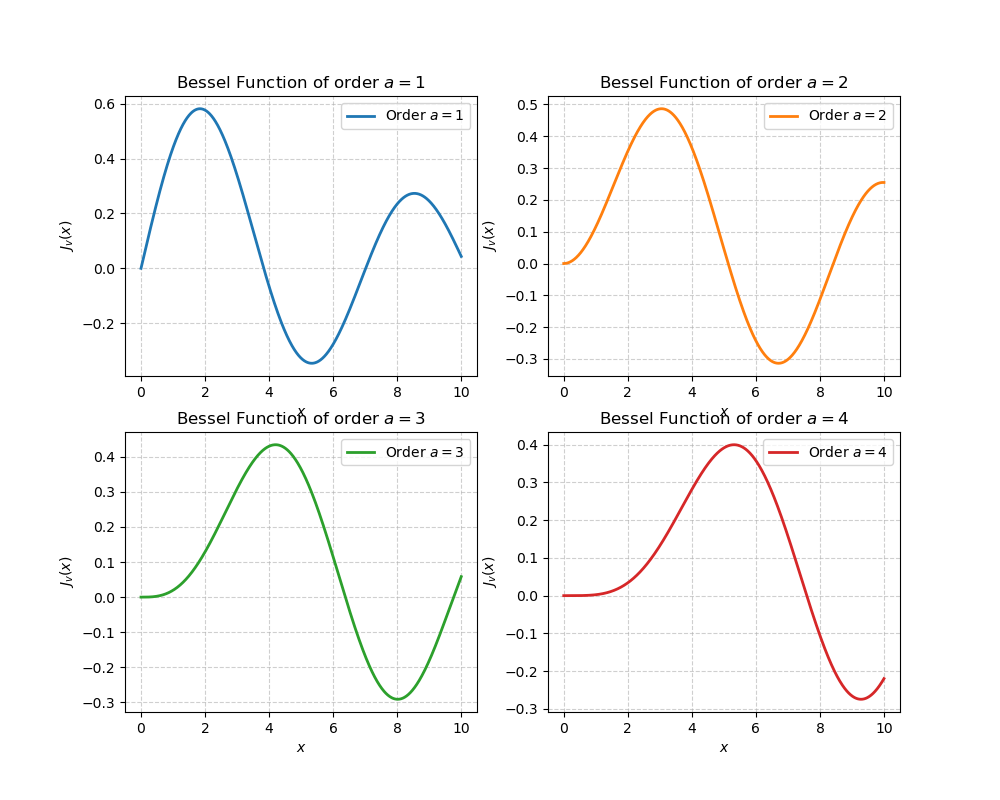

In [ ]:
# Leave unaltered
totalpoints += 3
currentpoints += 0.0

### Matplotlib, the right way (2 pt)  <font color='red'><b>HOMEWORK</b></font>

The following table contains the measurements of distances and velocities, including their uncertainties, for a small sample of galaxies. The table is given in the form of a Python list.

From your previous coursework, you have done chi-squared fitting to fit the following data without uncertainties. If considering the uncertainties during the fitting process, the slope of a best fit line through the data gives a value for the Hubble constant.

$$H_0 = 67.8 (km/s)/Mpc$$

```
    d(Mpc)    v(km/s)    error in d    error in v
    ==============================================
    18.49      2094.75    0.3           100
    35.48      2320.87    2.2           120
    ........
```
```python
    data = [
    18.49,     2094.75,    0.3,           100,
    35.48,     2320.87,    2.2,           120,
    35.48,     1224.9,     3.0,           80,
    11.34,     872.13,     1.2,           80,
    7.12,      432.2,      0.4,           70,
    9.82,      751,        0.3,           75,
    23.66,     1410,       2.3,           70,
    44,        2700,       4.0,           110,
    66.7,      5292,       5.3,           120,
    52.4,      2550,       5.2,           100,
    55,        5253,       6.1,           150,
    25.6,      2419,       3.2,           110,
    26.19,     2158,       2.8,           110
    ]
```

<font color='red'>In this question, you have to use the OO interface of Matplotlib to create your plot, or 1.0pt will be deducted.</font>

* Use slicing syntax to unpack ``data`` into separate variables for distance and velocity, as well as their corresponding errors.
* Create a plot for this data. Add error bars with method `errorbar() <matplotlib.axes.Axes.errorbar>`
* Plot also a line which represents the Hubble relation between distance and velocity  as a line through the origin, with a slope equal to $H_0$
* Add the value of $H_0$ to the legend using LaTex math mode
  
**Script and plot**:

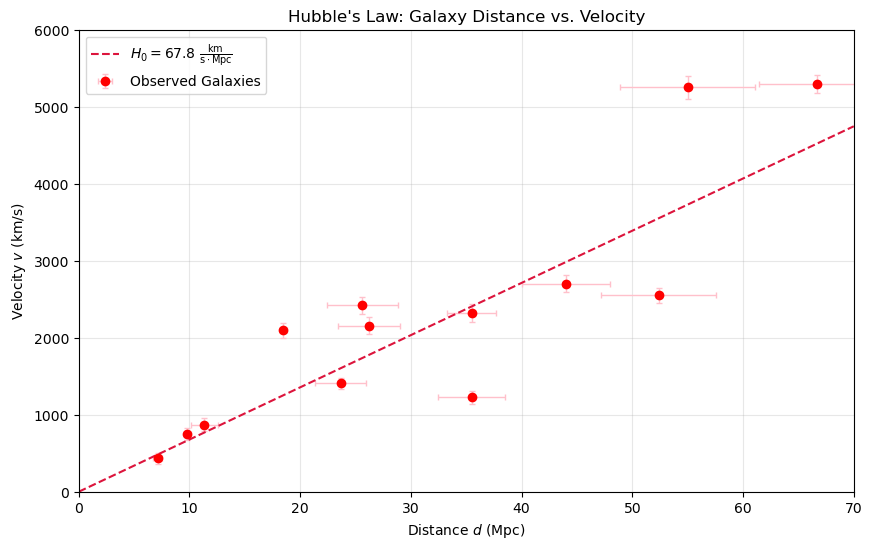

In [1]:
import numpy as np
import matplotlib.pyplot as plt

data = [
    18.49, 2094.75, 0.3, 100,
    35.48, 2320.87, 2.2, 120,
    35.48, 1224.9, 3.0, 80,
    11.34, 872.13, 1.2, 80,
    7.12, 432.2, 0.4, 70,
    9.82, 751, 0.3, 75,
    23.66, 1410, 2.3, 70,
    44, 2700, 4.0, 110,
    66.7, 5292, 5.3, 120,
    52.4, 2550, 5.2, 100,
    55, 5253, 6.1, 150,
    25.6, 2419, 3.2, 110,
    26.19, 2158, 2.8, 110
]

# Reshape
data_array = np.array(data).reshape(-1, 4)
# Sllicing 
dist = data_array[:, 0]
vel = data_array[:, 1]
dist_err = data_array[:, 2]
vel_err = data_array[:, 3]

# H0 line
h0 = 67.8
dist_range = np.linspace(0, 70, 100)
vel_hubble = h0 * dist_range

# 3. Create the plot using the OO interface
fig, ax = plt.subplots(figsize=(10, 6))

# Plot data with error bars
ax.errorbar(dist, vel, xerr=dist_err, yerr=vel_err, fmt='o', 
            color='Red', ecolor='pink', elinewidth=1, 
            capsize=2, label='Observed Galaxies')

# Plot the Hubble relation line (slope = H0, through origin)
ax.plot(dist_range, vel_hubble, color='crimson', linestyle='--', 
        label=rf'$H_0 = {h0} \ \frac{{\text{{km}}}}{{\text{{s}} \cdot \text{{Mpc}}}}$')

# Formatting
ax.set_xlabel('Distance $d$ (Mpc)')
ax.set_ylabel('Velocity $v$ (km/s)')
ax.set_title('Hubble\'s Law: Galaxy Distance vs. Velocity')
ax.set_xlim(0, 70)
ax.set_ylim(0, 6000)
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

In [ ]:
# Leave unaltered
totalpoints += 2
currentpoints += 0.0

## Finishing up

**Please read the section about your report in the task documentation very carefully before submitting it to BrightSpace.**

------------

## T.A. Grading


In [ ]:
# Leave unaltered
taskgrade = round(10*currentpoints/totalpoints, 1) if totalpoints != 0 else 0
print(f"Total number of points: {totalpoints}. Student score: {currentpoints}.  Task Grade = {taskgrade}")